In [32]:
# Import packages
import pandas as pd                 
import matplotlib.pyplot as plt     
import numpy as np                  
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import lightgbm as lgb
import shap
shap.initjs()

*The figures in the readme document was developed using a slightly different, preprocessed data set. The notebook below uses the original kaggle data set, and yields slightly different figures. The same principles apply.*

## 1. Data wrangling

Read the data from the source into a `pandas` data frame. The data can be downloaded from [kaggle](https://www.kaggle.com/datasets/edumagalhaes/quality-prediction-in-a-mining-process).

In [33]:
df_original = pd.read_csv(
    "data\MiningProcess_Flotation_Plant_Database.csv",
    decimal=',',
    index_col=0,
    parse_dates=[0]
 )
df_original.describe().T

<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
C:\Users\tmlouw\AppData\Local\Temp\ipykernel_30360\2380514855.py:2: SyntaxWarning: invalid escape sequence '\M'
  "data\MiningProcess_Flotation_Plant_Database.csv",


,count,mean,std,min,25%,50%,75%,max
% Iron Feed,737453.0,56.294739,5.157744,42.740000,52.670000,56.080000,59.720000,65.78000
% Silica Feed,737453.0,14.651716,6.807439,1.310000,8.940000,13.850000,19.600000,33.40000
Starch Flow,737453.0,2869.140569,1215.203734,0.002026,2076.320000,3018.430000,3727.730000,6300.23000
Amina Flow,737453.0,488.144697,91.230534,241.669000,431.796000,504.393000,553.257000,739.53800
Ore Pulp Flow,737453.0,397.578372,9.699785,376.249000,394.264000,399.249000,402.968000,418.64100
Ore Pulp pH,737453.0,9.767639,0.387007,8.753340,9.527360,9.798100,10.038000,10.80810
Ore Pulp Density,737453.0,1.680380,0.069249,1.519820,1.647310,1.697600,1.728330,1.85325
Flotation Column 01 Air Flow,737453.0,280.151856,29.621288,175.510000,250.281000,299.344000,300.149000,373.87100
Flotation Column 02 Air Flow,737453.0,277.159965,30.149357,175.156000,250.457000,296.223000,300.690000,375.99200
Flotation Column 03 Air Flow,737453.0,281.082397,28.558268,176.469000,250.855000,298.696000,300.382000,364.34600


In [34]:
df_original.head()

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,250.576,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,250.862,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,250.313,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,250.049,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,249.895,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31


Rename the columns for brevity.

In [35]:
## Rename columns (variables) for easier interpretation
df_renamed = df_original.copy()

# Create cleaner variable names and units separately
variable_names = ['Feed Fe', 'Feed Si', 'Starch Flow', 'Amina Flow', 'Feed Flow', 'Feed pH', 'Feed Density'] + \
                ['Air Flow C1', 'Air Flow C2', 'Air Flow C3', 'Air Flow C4', 'Air Flow C5', 'Air Flow C6', 'Air Flow C7'] + \
                ['Level C1', 'Level C2', 'Level C3', 'Level C4', 'Level C5', 'Level C6', 'Level C7'] + \
                ['Product Fe', 'Product Si']

df_renamed.columns = variable_names
# Downsample to 15 minute intervals, taking the mean of each interval, and drop any remaining NaN values
df = df_renamed.resample('15min').mean().dropna()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Feed Fe,4097.0,56.294730,5.158347,42.740000,52.670000,56.080000,59.720000,65.780000
Feed Si,4097.0,14.651733,6.808236,1.310000,8.940000,13.850000,19.600000,33.400000
Starch Flow,4097.0,2869.142009,950.480080,54.595483,2168.968993,2908.340847,3528.727412,6270.158798
Amina Flow,4097.0,488.145318,83.689937,242.927477,436.037967,502.454283,549.522256,736.982378
Feed Flow,4097.0,397.578386,8.370683,376.837604,398.851356,399.842656,400.589883,418.070232
Feed pH,4097.0,9.767642,0.378027,8.753389,9.540878,9.795850,10.030779,10.807370
Feed Density,4097.0,1.680380,0.063775,1.519926,1.651352,1.695705,1.721790,1.832430
Air Flow C1,4097.0,280.151579,29.410048,175.885579,250.089767,299.837839,299.951350,312.295415
Air Flow C2,4097.0,277.159709,29.423337,178.188430,250.096872,299.526717,299.979900,309.887767
Air Flow C3,4097.0,281.082104,28.373511,177.202665,250.087672,299.888089,299.946594,302.783000


## 2. Dimensionality reduction and clustering

Perform dimensionality reduction using PLS.

PLS (6 components)  |  R² = 0.1427  |  RMSE = 1.0284


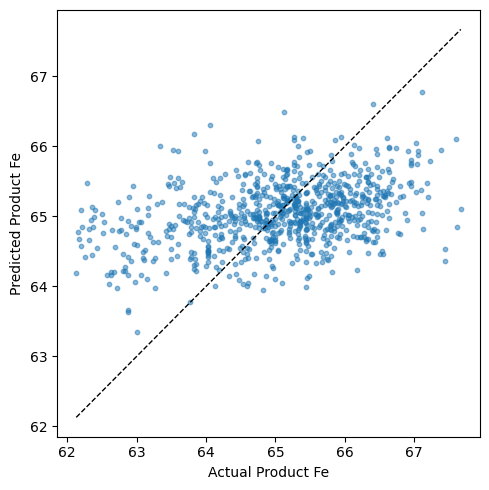

In [36]:
# --- Drop target and excluded features from df_full ---
df_model = df.drop(['Product Fe', 'Product Si', 'Feed Fe', 'Feed Si'], axis=1)

X = df_model.values
y = df['Product Fe'].values

# Standardise inputs and split(PLS is sensitive to scale)
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# --- Fit PLS (choose n_components via cross-validation below) ---
n_components = 6
pls = PLSRegression(n_components=n_components)
pls.fit(X_train, y_train)
y_pred = pls.predict(X_test).ravel()
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"PLS ({n_components} components)  |  R² = {r2:.4f}  |  RMSE = {rmse:.4f}")

# --- Parity plot ---
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, y_pred, s=10, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel('Actual Product Fe')
ax.set_ylabel('Predicted Product Fe')
plt.tight_layout()
plt.show()

# --- Project X into PLS latent space ---
T = pls.transform(X_scaled)

Perform clustering using k-means clustering.

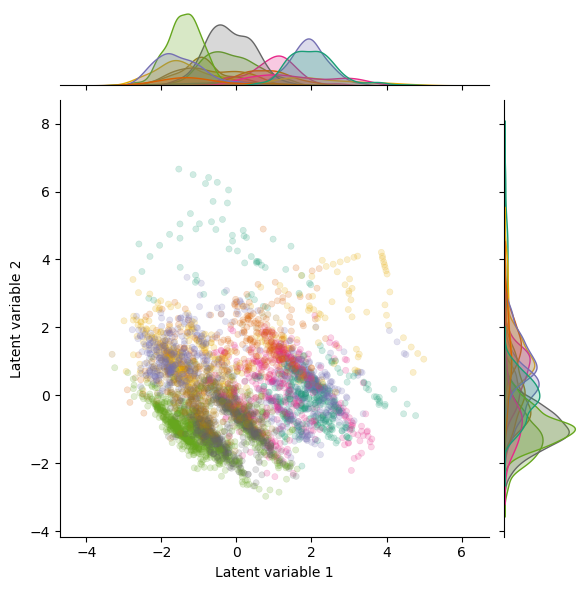

In [37]:
n_clusters = 15
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
pls_labels = kmeans.fit_predict(T)

plot_data = pd.DataFrame({'Latent variable 1': T[:, 0], 'Latent variable 2': T[:, 1], 'Cluster': pls_labels})
sns.jointplot(data=plot_data, x='Latent variable 1', y='Latent variable 2', hue='Cluster', palette='Dark2', 
              alpha=0.2, s=20, edgecolor=None, legend=False)
plt.show()

Plot each feature as a time series coloured according to cluster label.

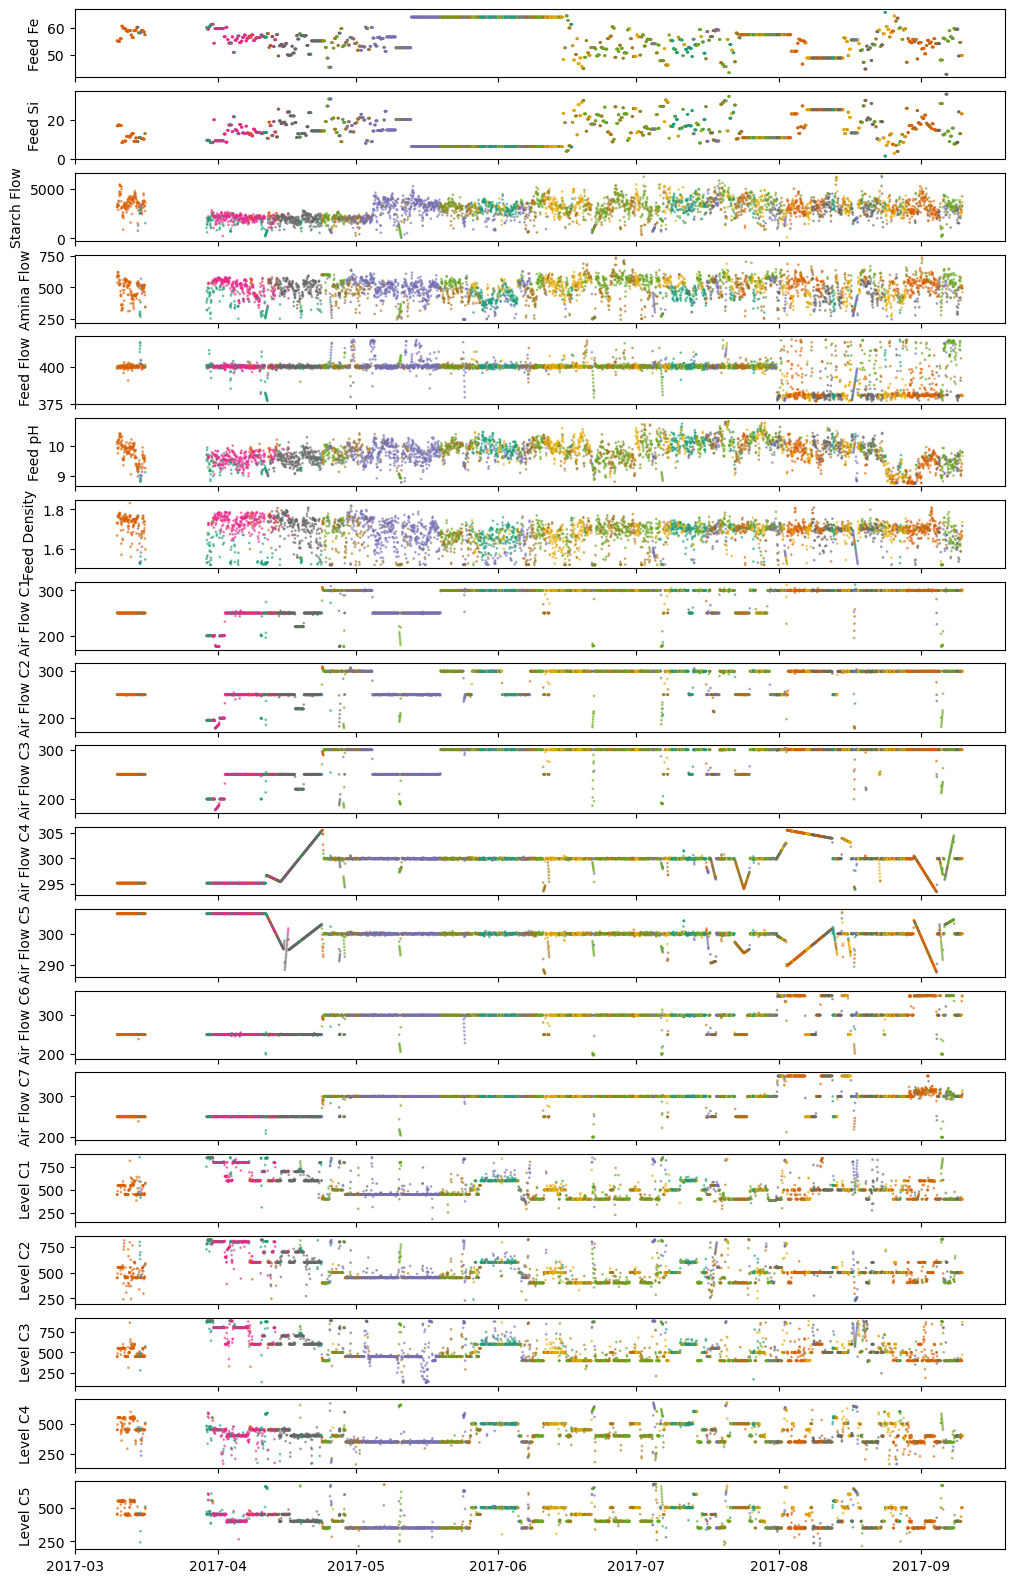

In [38]:
fig, ax = plt.subplots(19,1, figsize=(12, 20), sharex=True)
for (ax, col) in zip(ax.flatten(), df.columns):
    ax.scatter(df.index, df[col], c = pls_labels, s=1, cmap = 'Dark2', alpha = 0.5)
    ax.set_ylabel(col)   

Let's try to reduce the number of transitions by combining clusters together.

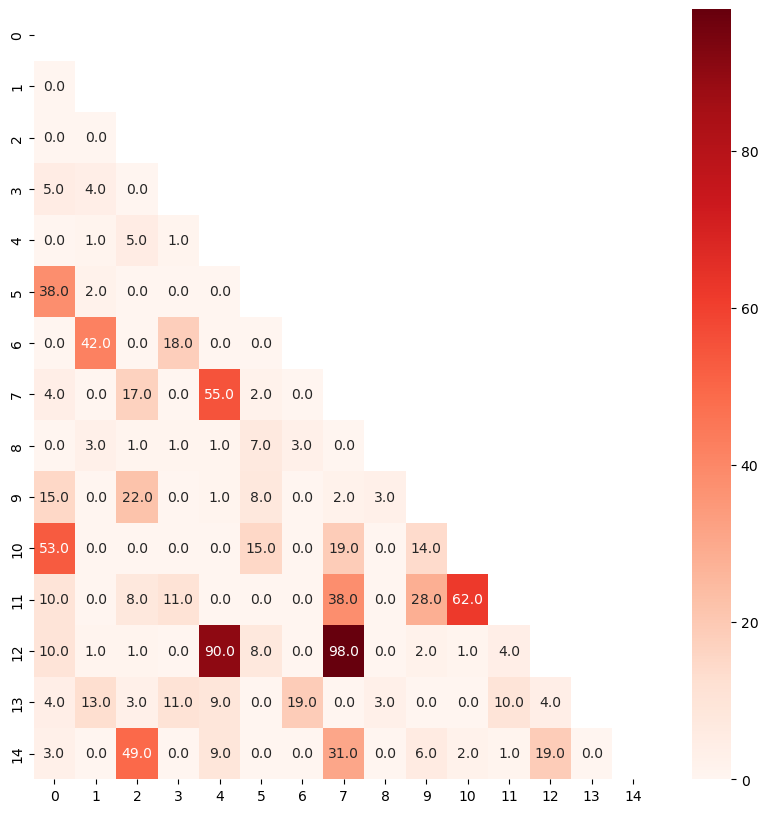

In [39]:
cluster_metric = pd.DataFrame({'Cluster t_{k}': pls_labels[:-1], 
                               'Cluster t_{k+1}': pls_labels[1:]})
cm = confusion_matrix(cluster_metric['Cluster t_{k}'], 
                      cluster_metric['Cluster t_{k+1}']) + 0.
cm += cm.T
cm[np.triu_indices_from(cm)] = np.nan

plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='.1f', cmap='Reds')
plt.show()

Join clusters together where the transitions exceed a specific threshold (in this case, 100).

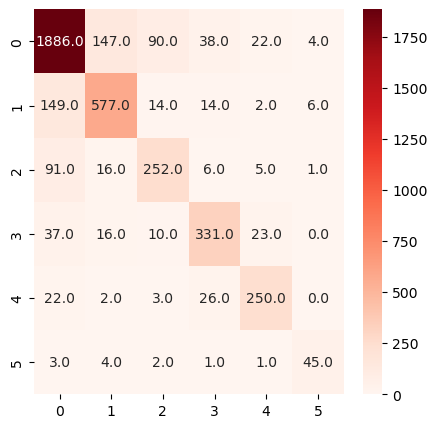

In [40]:
join = [(0,4,6,7,9,10), (5,12,13), (1,11), (3,14), (2,), (8,)]
cluster_mapping = {}
for new_label, group in enumerate(join):
    for old_label in group:
        cluster_mapping[old_label] = new_label
pls_labels_joined = np.array([cluster_mapping.get(k) for k in pls_labels])

cluster_metric_joined = pd.DataFrame({'Cluster t_{k}': pls_labels_joined[:-1], 
                                      'Cluster t_{k+1}': pls_labels_joined[1:]})
cm = confusion_matrix(cluster_metric_joined['Cluster t_{k}'], 
                      cluster_metric_joined['Cluster t_{k+1}']) + 0.


plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='.1f', cmap='Reds')
plt.show()

C:\Users\tmlouw\AppData\Local\Temp\ipykernel_30360\1687847462.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['ordered_cluster_label'], y=df['Product Fe'], ax=ax, palette='Dark2')


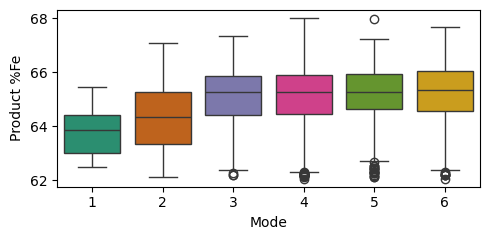

In [41]:
# Compute mean Product Fe per cluster label
means = pd.Series(df['Product Fe']).groupby(pls_labels_joined).mean()
label_order_map = {label: i+1 for i, label in enumerate(means.sort_values().index.tolist())}
df['ordered_cluster_label'] = [label_order_map[l] for l in pls_labels_joined]

fig, ax = plt.subplots(figsize=(5, 2.5))
sns.boxplot(x=df['ordered_cluster_label'], y=df['Product Fe'], ax=ax, palette='Dark2')
ax.set_xlabel('Mode')
ax.set_ylabel('Product %Fe')
plt.tight_layout()
plt.show()

# 3. Mode labelling
Perform SHAP analysis to describe individual modes

In [42]:
# Train basic LightGBM classifier
lgb_classifier = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    verbose=-1  # Suppress warnings
)

y_pred = lgb_classifier.fit(df_model, df['ordered_cluster_label'])
y_pred = lgb_classifier.predict(df_model)
print(accuracy_score(df['ordered_cluster_label'], y_pred))

0.9973151086160605


In [43]:
# Initialize the SHAP explainer for the gradient boosting classifier
explainer = shap.TreeExplainer(lgb_classifier)
shap_values = explainer.shap_values(df_model)

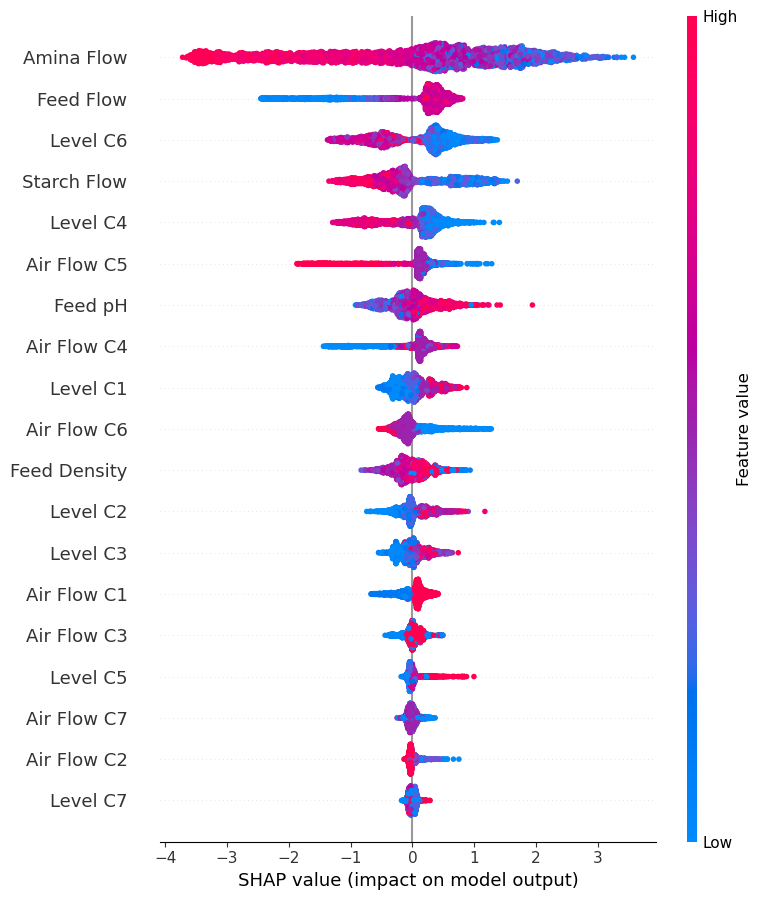

In [46]:
c = 5
shap.summary_plot(shap_values[:,:,c-1], df_model)

# 4. Transitions

Plot the inputs coloured according to clusters

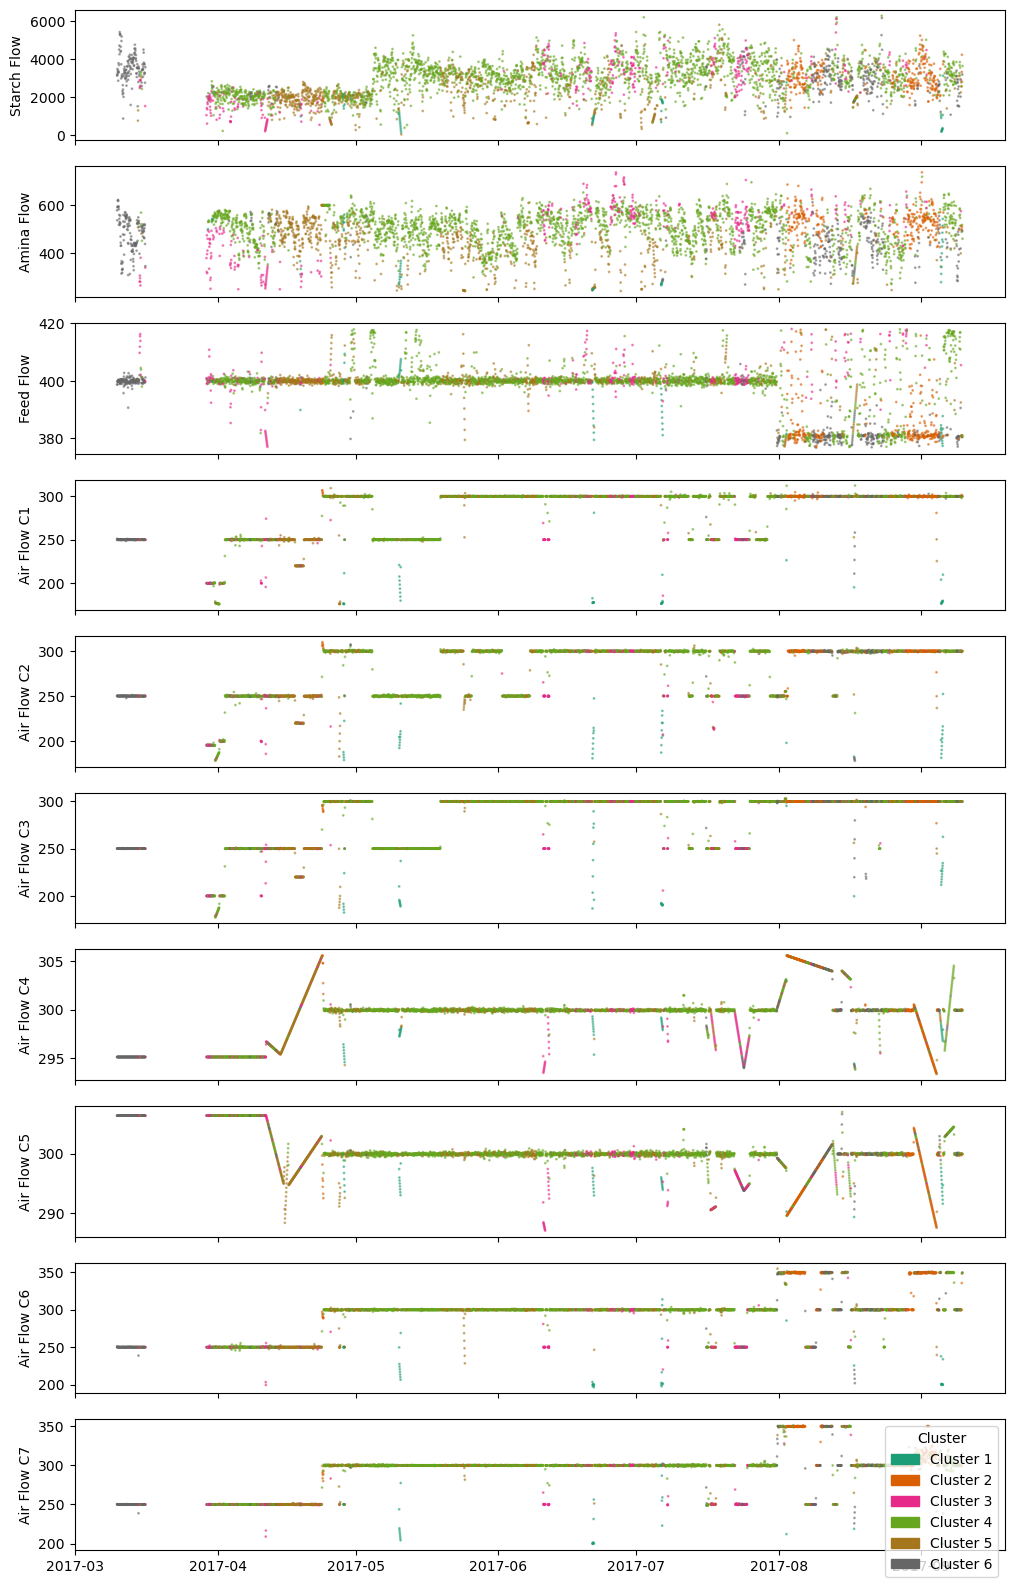

In [45]:
inputs = ['Starch Flow', 'Amina Flow', 'Feed Flow',] + \
                ['Air Flow C1', 'Air Flow C2', 'Air Flow C3', 'Air Flow C4', 'Air Flow C5', 'Air Flow C6', 'Air Flow C7']
fig, ax = plt.subplots(10,1, figsize=(12, 20), sharex=True)
for (ax, col) in zip(ax.flatten(), inputs):
    scatter = ax.scatter(df.index, df[col], c=df['ordered_cluster_label'], s=1, cmap='Dark2', alpha=0.5)
    ax.set_ylabel(col)

# Add legend for cluster labels
import matplotlib.patches as mpatches
unique_labels = np.unique(df['ordered_cluster_label'])
legend_handles = [mpatches.Patch(color=scatter.cmap(scatter.norm(l)), label=f'Cluster {l}') for l in unique_labels]
ax.legend(handles=legend_handles, loc='upper right', title='Cluster')
